![Banner](../Image/03_DeepCuaslaML.png)


# 3.1 Continuous Optimization Models (NOTEARS)

> **Note:** NOTEARS requires **PyTorch**. The `NOTEARSLinear`, `NOTEARSNonlinearMLP`, and `NOTEARSNonlinearSobolev` estimators in `pydeepcausalml.discovery` learn DAG structure via a smooth acyclicity constraint.

**NOTEARS** ("DAGs with NO TEARS", Zheng et al., NeurIPS 2018) introduced a landmark reformulation of causal structure learning: instead of exhaustively searching the combinatorial space of $2^{O(d^2)}$ possible directed acyclic graphs (an approach that becomes intractable for more than roughly ten variables), it recasts the problem as a **smooth, gradient-based optimization** over a real-valued weighted adjacency matrix $\mathbf{W} \in \mathbb{R}^{d \times d}$.

Under the **linear Structural Equation Model (SEM)** assumption

$$\mathbf{X} = \mathbf{X}\mathbf{W} + \mathbf{Z},$$

where $\mathbf{Z}$ contains independent noise terms (commonly Gaussian), the algorithm simultaneously (i) fits $\mathbf{W}$ to the data via a reconstruction loss, (ii) enforces acyclicity through a closed-form differentiable constraint, and (iii) promotes sparsity with an $\ell_1$ penalty.

**Key innovation — the acyclicity constraint.** The function

$$h(\mathbf{W}) = \mathrm{tr}\!\left(\exp(\mathbf{W} \odot \mathbf{W})\right) - d$$

equals zero *if and only if* the graph encoded by $\mathbf{W}$ is acyclic. Because $h$ is smooth and differentiable, the NP-hard combinatorial constraint is replaced by an equality constraint amenable to augmented Lagrangian (AL) optimization — no combinatorial search required.

NOTEARS is concise (the core algorithm fits in fewer than 60 lines of code), fast for moderate graph sizes ($d \leq 100$–$200$), and has become the canonical baseline against which all later continuous causal discovery methods are benchmarked — including GOLEM, DAG-GNN, and GraN-DAG.

![](../Image/NOTEARS.png)


## NOTEARS with PyDeepCausalML

This notebook implements both the **linear** and **nonlinear** NOTEARS variants in Python using the **PyDeepCausalML** package. We apply them to synthetic data (linear and nonlinear SEMs) and evaluate performance against known ground-truth DAGs.

The **PyDeepCausalML** package encodes the full NOTEARS family. The acyclicity constraint $h(W) = \mathrm{tr}(e^{W \odot W}) - d = 0$ is enforced via the trace of the matrix exponential, and optimization is handled by the augmented Lagrangian method with Adam inner steps.

**Linear NOTEARS** (`NOTEARSLinear`) learns a weighted adjacency matrix $W$ by minimizing a least-squares loss plus an $\ell_1$ penalty subject to $h(W) = 0$.

**Nonlinear NOTEARS** (`NOTEARSNonlinearMLP`, `NOTEARSNonlinearSobolev`) replace the linear predictor with either an MLP or a Sobolev-basis model, allowing the algorithm to capture arbitrary smooth nonlinear relationships while keeping the same acyclicity constraint.

### Main Classes

| Class | Role |
|------------------------------------|------------------------------------|
| `NOTEARSLinear` | Linear NOTEARS: L2 loss + L1, augmented Lagrangian |
| `NOTEARSNonlinearMLP` | Nonlinear NOTEARS with MLP per node |
| `NOTEARSNonlinearSobolev` | Nonlinear NOTEARS with Sobolev / polynomial basis |

### Simulation and Evaluation Utilities

| Function | Role |
|------------------------------------|------------------------------------|
| `is_dag` | Check whether a weighted adjacency matrix encodes a DAG |
| `simulate_dag` | Simulate a random DAG (Erdős–Rényi or scale-free) |
| `simulate_parameter` | Draw edge weights for a DAG |
| `simulate_linear_sem` | Generate data from a linear SEM |
| `simulate_nonlinear_sem_custom` | Generate data from a nonlinear SEM |
| `count_accuracy` / `graph_recovery_metrics` | Compare estimated graph to ground truth |

**Reference:** Zheng, X., Aragam, B., Ravikumar, P., & Xing, E. P. (2018). DAGs with NO TEARS: Continuous optimization for structure learning. *NeurIPS*. <https://arxiv.org/abs/1803.01422>.


## Setup

### Check and Install Required Python Packages


In [1]:
import importlib
import subprocess
import sys

PACKAGES = [
    "numpy", "pandas", "scipy", "torch", "scikit-learn",
    "matplotlib", "seaborn", "networkx",
]

for pkg in PACKAGES:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import pydeepcausalml  # noqa: F401
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/zia207/PyDeepCausalML.git"]
    )

import pydeepcausalml
print("pydeepcausalml", pydeepcausalml.__version__, "ready.")


pydeepcausalml 0.2.0 ready.


### Verify imports


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LinearRegression

from pydeepcausalml import set_seed
from pydeepcausalml.metrics import graph_recovery_metrics, shd, pehe

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.12.1+cu130
cuda: False


In [3]:
set_seed(42)
run_fast = True


### Simulation utilities


In [4]:
"""Simulation and evaluation helpers (NOTEARS tutorial utilities)."""

def is_dag(W: np.ndarray, tol: float = 1e-8) -> bool:
    """Return True if weighted matrix W encodes a DAG."""
    d = W.shape[0]
    m = (np.abs(W) > tol).astype(float)
    acc = m.copy()
    for _ in range(d):
        if np.trace(acc) > tol:
            return False
        acc = acc @ m
    return True


def simulate_dag(d: int, s0: int, graph_type: str = "ER", seed: int | None = None) -> np.ndarray:
    """Simulate a random binary DAG adjacency (A[i,j]=1 => X_j -> X_i)."""
    rng = np.random.default_rng(seed)
    if graph_type.upper() == "ER":
        prob = min(1.0, s0 / max(d * (d - 1) / 2, 1))
        B = np.triu(rng.random((d, d)) < prob, k=1).astype(int)
    else:  # scale-free-ish upper triangular
        B = np.zeros((d, d), dtype=int)
        edges = 0
        while edges < s0:
            i, j = rng.integers(0, d, size=2)
            if i < j and B[i, j] == 0:
                B[i, j] = 1
                edges += 1
    return B


def simulate_parameter(B: np.ndarray, low: float = 0.5, high: float = 2.0, seed: int | None = None) -> np.ndarray:
    """Draw edge weights for a binary DAG."""
    rng = np.random.default_rng(seed)
    W = np.zeros_like(B, dtype=float)
    mask = B.astype(bool)
    signs = rng.choice([-1.0, 1.0], size=mask.sum())
    W[mask] = signs * rng.uniform(low, high, size=mask.sum())
    return W


def simulate_linear_sem(W: np.ndarray, n: int, sem_type: str = "gauss", seed: int | None = None) -> np.ndarray:
    """Generate data from a linear SEM in topological order.

    With an upper-triangular weight matrix ``W`` (``W[i, j] != 0`` means
    ``X_i -> X_j``), each node is drawn as ``X_j = sum_i W[i, j] X_i + Z_j``.
    Sampling node-by-node in index order is exact here because parents always
    have a smaller index than their children.
    """
    rng = np.random.default_rng(seed)
    d = W.shape[0]
    X = np.zeros((n, d))
    for j in range(d):
        parents = np.where(W[:, j] != 0)[0]
        noise = rng.standard_normal(n) if sem_type == "gauss" else rng.exponential(size=n)
        if len(parents):
            X[:, j] = X[:, parents] @ W[parents, j] + noise
        else:
            X[:, j] = noise
    return X


def count_accuracy(B_true: np.ndarray, B_est: np.ndarray) -> dict:
    """Compare estimated graph to ground truth (FDR, TPR, FPR, SHD, nnz)."""
    m = graph_recovery_metrics(B_true, B_est)
    tp, fp, fn = m["tp"], m["fp"], m["fn"]
    tn = int((~np.eye(B_true.shape[0], dtype=bool)).sum()) - tp - fp - fn
    fdr = fp / (tp + fp) if tp + fp else 0.0
    tpr = m["recall"]
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return {"fdr": fdr, "tpr": tpr, "fpr": fpr, "shd": m["shd"], "nnz": int(B_est.sum())}


def simulate_nonlinear_sem_custom(W: np.ndarray, n: int, sem_type: str = "mlp", noise_sd: float = 0.5, seed: int | None = None) -> np.ndarray:
    """Nonlinear SEM with additive noise (A[i,j]: j->i)."""
    rng = np.random.default_rng(seed)
    d = W.shape[0]
    G = nx.DiGraph((j, i) for i in range(d) for j in range(d) if W[i, j] != 0)
    order = list(nx.topological_sort(G)) if G.number_of_edges() else list(range(d))
    X = np.zeros((n, d))
    for i in order:
        pa = np.where(W[i, :] != 0)[0]
        if len(pa) == 0:
            X[:, i] = rng.standard_normal(n)
        else:
            z = X[:, pa] @ W[i, pa]
            if sem_type == "mlp":
                X[:, i] = np.tanh(z) + rng.normal(0, noise_sd, n)
            elif sem_type == "mim":
                X[:, i] = z * np.sin(z) + rng.normal(0, noise_sd, n)
            elif sem_type == "gp":
                X[:, i] = np.sin(z) + rng.normal(0, noise_sd, n)
            else:
                X[:, i] = z + rng.standard_normal(n)
    return X


---

## Part I: Linear NOTEARS on Synthetic Gaussian Data

### Overview

We begin with a **linear Gaussian SEM**: variables are generated by the model $\mathbf{X} = \mathbf{X}\mathbf{W} + \mathbf{Z}$, where $\mathbf{Z} \sim \mathcal{N}(0, I)$. The ground-truth DAG is known, so we can measure recovery accuracy precisely.

### Data Generation and Preprocessing


In [5]:
# Dataset 1: Linear Gaussian SEM (d = 20)
set_seed(42)

n_lin, d_lin, s0_lin = 2000, 20, 20
graph_type, sem_type_lin = "ER", "gauss"

B_true_lin = simulate_dag(d_lin, s0_lin, graph_type, seed=42)
W_true_lin = simulate_parameter(B_true_lin, seed=42)
X_lin = simulate_linear_sem(W_true_lin, n_lin, sem_type_lin, seed=42)

# Center columns — NOTEARS is sensitive to variable scale
X_lin = X_lin - X_lin.mean(axis=0, keepdims=True)

rng = np.random.default_rng(42)
idx = rng.permutation(n_lin)
tr1 = idx[: int(0.70 * n_lin)]
tmp1 = idx[int(0.70 * n_lin) :]
va1 = tmp1[: len(tmp1) // 2]
te1 = tmp1[len(tmp1) // 2 :]

X_lin_train, X_lin_val, X_lin_test = X_lin[tr1], X_lin[va1], X_lin[te1]
print("Linear SEM — Train:", X_lin_train.shape, "| Val:", X_lin_val.shape, "| Test:", X_lin_test.shape)


Linear SEM — Train: (1400, 20) | Val: (300, 20) | Test: (300, 20)


### Fitting Linear NOTEARS

The algorithm minimizes the augmented Lagrangian

$$\mathcal{L}_\rho(W, \alpha) = \frac{1}{2n}\|X - XW\|_F^2 + \lambda_1\|W\|_1 + \alpha\, h(W) + \frac{\rho}{2}h(W)^2,$$

iterating (i) gradient steps on $W$ and (ii) dual-ascent updates until $h(W) < \epsilon$.


In [6]:
from pydeepcausalml.discovery import NOTEARSLinear

model_lin = NOTEARSLinear(
    lambda_l1=0.05,
    epochs=100,
    n_outer=100,
    lr=1e-2,
    random_state=42,
)
model_lin.fit(X_lin_train)

W_est_lin = model_lin.weights_
w_threshold = 0.3
B_est_lin = model_lin.get_adjacency(threshold=w_threshold)

print("Acyclic (thresholded, linear SEM):", is_dag(B_est_lin))
n_val_lin = X_lin_val.shape[0]
val_loss_lin = 0.5 / n_val_lin * np.sum((X_lin_val - X_lin_val @ W_est_lin.T) ** 2)
print(f"Validation L2 loss (linear model | linear SEM): {val_loss_lin:.6f}")


Acyclic (thresholded, linear SEM): True
Validation L2 loss (linear model | linear SEM): 25.046984


**Hyperparameter guidance.** The two most impactful choices are: (i) the sparsity penalty $\lambda_1 \in [0.01, 0.5]$ — higher values prune more edges; and (ii) the edge-threshold $w_{\mathrm{threshold}} \in [0.1, 0.5]$ applied after optimization.

### Causal Effect Estimation via Backdoor Adjustment

NOTEARS recovers **graph structure**, not causal effects directly. Once the DAG is in hand, downstream causal inference proceeds in two steps: (i) read off a valid adjustment set from the graph using the backdoor criterion, and (ii) estimate the Average Treatment Effect (ATE) by regression on that set.

The example below treats variable 0 as the treatment $T$ and variable 19 as the outcome $Y$ (0-indexed).


In [7]:
# True ATE via structural path sum: (I - W)^{-1}[Y, T]
I_lin = np.eye(d_lin)
true_total_lin = np.linalg.solve(I_lin - W_true_lin, np.eye(d_lin))
true_ATE_lin = true_total_lin[19, 0]
print(f"True ATE (T -> Y, linear SEM):  {true_ATE_lin:.4f}")

confounders_idx_lin = [i for i in range(d_lin) if i not in (0, 19)]
T_tr_lin = X_lin_train[:, 0:1]
Y_tr_lin = X_lin_train[:, 19]
C_tr_lin = X_lin_train[:, confounders_idx_lin]

model_ate_lin = LinearRegression().fit(np.hstack([T_tr_lin, C_tr_lin]), Y_tr_lin)
est_ATE_lin = model_ate_lin.coef_[0]
print(f"Estimated ATE:  {est_ATE_lin:.4f}  (error: {abs(est_ATE_lin - true_ATE_lin):.4f})")


True ATE (T -> Y, linear SEM):  0.0000
Estimated ATE:  -0.0539  (error: 0.0539)


### Graph Recovery Metrics

When the ground-truth DAG is known, five complementary metrics quantify structural recovery accuracy.

- **FDR** — fraction of predicted edges that are spurious.
- **TPR (Recall)** — fraction of true edges recovered.
- **FPR** — fraction of true non-edges incorrectly predicted.
- **SHD** — edge insertions + deletions to match the true graph.
- **nnz** — number of edges in the estimated graph.


In [8]:
acc_lin_result = count_accuracy(B_true_lin, B_est_lin)
print(acc_lin_result)


{'fdr': 0.6153846153846154, 'tpr': 0.2941, 'fpr': 0.02203856749311295, 'shd': 20, 'nnz': 13}


### Visualization

#### Weighted Adjacency Matrix


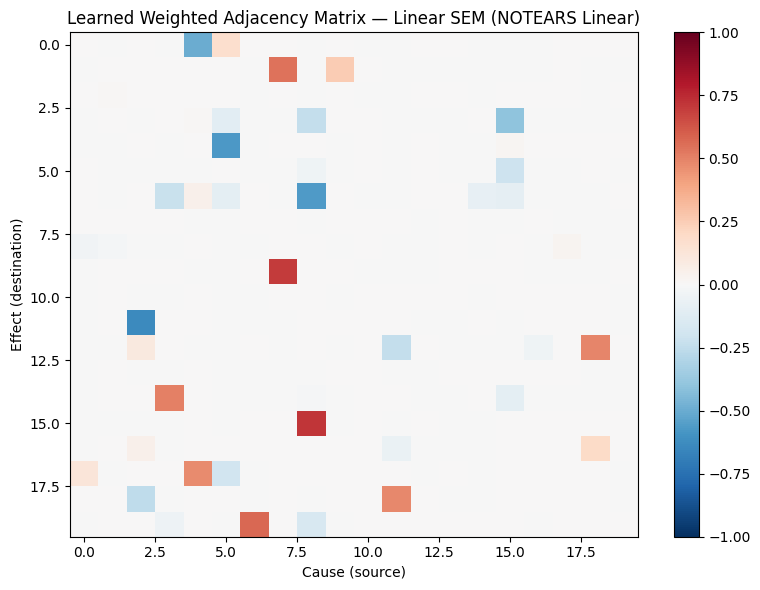

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(W_est_lin, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Learned Weighted Adjacency Matrix — Linear SEM (NOTEARS Linear)")
ax.set_xlabel("Cause (source)")
ax.set_ylabel("Effect (destination)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


#### Learned Causal DAG


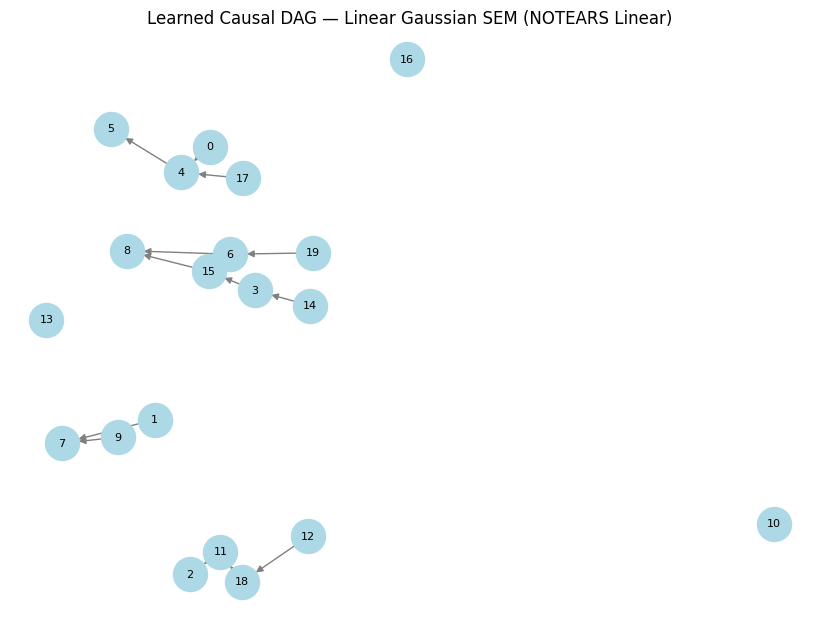

In [10]:
G_lin = nx.from_numpy_array((np.abs(W_est_lin) > w_threshold).astype(int), create_using=nx.DiGraph)
pos_lin = nx.spring_layout(G_lin, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G_lin, pos_lin, with_labels=True, node_color="lightblue", arrows=True,
        node_size=600, font_size=8, edge_color="gray")
plt.title("Learned Causal DAG — Linear Gaussian SEM (NOTEARS Linear)")
plt.show()


---

## Part II: Nonlinear NOTEARS (MLP and Sobolev) vs. Misspecified Baseline

### Overview

We now stress-test the linear model on data generated from a **nonlinear SEM** and compare it against two nonlinear NOTEARS variants.


In [11]:
# Dataset 2: Nonlinear SEM (d = 10)
set_seed(42)
n_nlin, d_nlin, s0_nlin = 2000, 10, 10
B_true_nlin = simulate_dag(d_nlin, s0_nlin, graph_type, seed=42)
W_true_nlin = simulate_parameter(B_true_nlin, seed=42)
X_nlin = simulate_nonlinear_sem_custom(W_true_nlin, n_nlin, sem_type="mlp", seed=42)
X_nlin = X_nlin - X_nlin.mean(axis=0, keepdims=True)

rng = np.random.default_rng(42)
idx = rng.permutation(n_nlin)
tr2 = idx[: int(0.70 * n_nlin)]
tmp2 = idx[int(0.70 * n_nlin) :]
va2 = tmp2[: len(tmp2) // 2]
te2 = tmp2[len(tmp2) // 2 :]
X_nlin_train, X_nlin_val, X_nlin_test = X_nlin[tr2], X_nlin[va2], X_nlin[te2]
print("Nonlinear SEM — Train:", X_nlin_train.shape, "| Val:", X_nlin_val.shape, "| Test:", X_nlin_test.shape)


Nonlinear SEM — Train: (1400, 10) | Val: (300, 10) | Test: (300, 10)


### Model 1: Linear NOTEARS (Misspecified Baseline)


In [12]:
model_lin_nl = NOTEARSLinear(lambda_l1=0.1, epochs=100, n_outer=100, random_state=42)
model_lin_nl.fit(X_nlin_train)
W_lin_nlin = model_lin_nl.weights_
B_lin_nlin = model_lin_nl.get_adjacency(threshold=0.3)
print("Linear NOTEARS on nonlinear SEM — acyclic:", is_dag(B_lin_nlin))
n_val_nlin = X_nlin_val.shape[0]
val_loss_lin_nl = 0.5 / n_val_nlin * np.sum((X_nlin_val - X_nlin_val @ W_lin_nlin.T) ** 2)
print(f"Validation L2 loss (linear model | nonlinear SEM): {val_loss_lin_nl:.6f}")


Linear NOTEARS on nonlinear SEM — acyclic: True
Validation L2 loss (linear model | nonlinear SEM): 2.599821


### Model 2: NOTEARSNonlinearMLP


NOTEARSNonlinearMLP on nonlinear SEM — acyclic: False


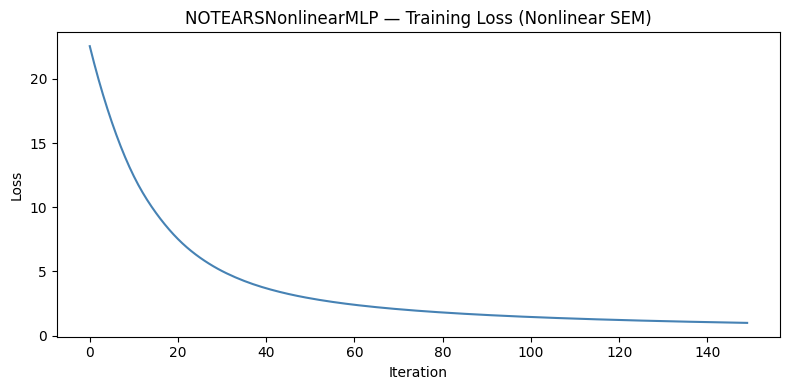

In [13]:
from pydeepcausalml.discovery import NOTEARSNonlinearMLP, NOTEARSNonlinearSobolev

set_seed(42)
model_mlp = NOTEARSNonlinearMLP(hidden=10, lambda1=0.01, rho=1.0, epochs=150, lr=1e-2, random_state=42)
model_mlp.fit(X_nlin_train)
W_mlp_nlin = model_mlp.adjacency_matrix()
B_mlp_nlin = (W_mlp_nlin > 1e-5).astype(int)
print("NOTEARSNonlinearMLP on nonlinear SEM — acyclic:", is_dag(B_mlp_nlin))

if model_mlp.history_.get("loss"):
    plt.figure(figsize=(8, 4))
    plt.plot(model_mlp.history_["loss"], color="steelblue")
    plt.title("NOTEARSNonlinearMLP — Training Loss (Nonlinear SEM)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


### Model 3: NOTEARSNonlinearSobolev


NOTEARSNonlinearSobolev on nonlinear SEM — acyclic: False


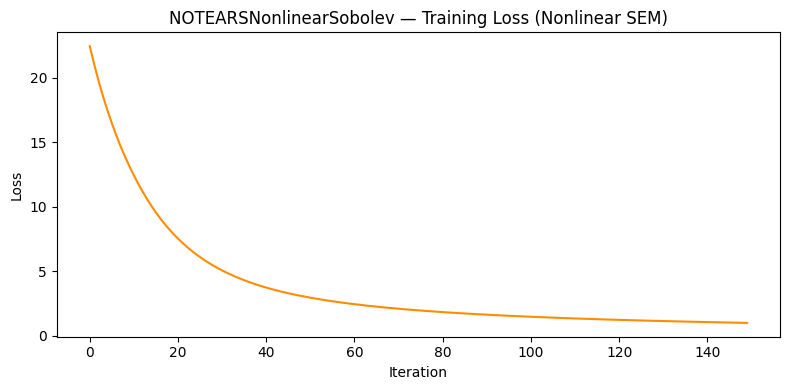

In [14]:
set_seed(42)
model_sob = NOTEARSNonlinearSobolev(degree=4, lambda1=0.01, rho=1.0, epochs=150, lr=1e-2, random_state=42)
model_sob.fit(X_nlin_train)
W_sob_nlin = model_sob.adjacency_matrix()
B_sob_nlin = (W_sob_nlin > 1e-5).astype(int)
print("NOTEARSNonlinearSobolev on nonlinear SEM — acyclic:", is_dag(B_sob_nlin))

if model_sob.history_.get("loss"):
    plt.figure(figsize=(8, 4))
    plt.plot(model_sob.history_["loss"], color="darkorange")
    plt.title("NOTEARSNonlinearSobolev — Training Loss (Nonlinear SEM)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


### Model Comparison


In [15]:
def safe_acc(B_true, W_est, B_est, label):
    if not is_dag(W_est):
        print(f"  {label:30s}  NOT a DAG — skipping metrics")
        return None
    return count_accuracy(B_true, B_est)

acc_lin_on_nlin = safe_acc(B_true_nlin, W_lin_nlin, B_lin_nlin, "Linear NOTEARS (nonlin SEM)")
acc_mlp_on_nlin = safe_acc(B_true_nlin, W_mlp_nlin, B_mlp_nlin, "NOTEARSNonlinearMLP")
acc_sob_on_nlin = safe_acc(B_true_nlin, W_sob_nlin, B_sob_nlin, "NOTEARSNonlinearSobolev")

def print_row(label, acc):
    if acc is None:
        print(f"  {label:34s} {'--':>7s} {'--':>7s} {'--':>7s} {'--':>5s} {'--':>5s}")
    else:
        print(f"  {label:34s} {acc['fdr']:7.4f} {acc['tpr']:7.4f} {acc['fpr']:7.4f} {acc['shd']:5d} {acc['nnz']:5d}")

div = "-" * 72
print("\n", div)
print(f"  {'Model':34s} {'FDR':>7s} {'TPR':>7s} {'FPR':>7s} {'SHD':>5s} {'nnz':>5s}")
print(div)
print(f"  {'Linear NOTEARS — native SEM *':34s} {acc_lin_result['fdr']:7.4f} {acc_lin_result['tpr']:7.4f} {acc_lin_result['fpr']:7.4f} {acc_lin_result['shd']:5d} {acc_lin_result['nnz']:5d}   (d=20, linear SEM)")
print(div)
print_row("Linear NOTEARS  (misspecified baseline)", acc_lin_on_nlin)
print_row("NOTEARSNonlinearMLP (hidden=10)", acc_mlp_on_nlin)
print_row("NOTEARSNonlinearSobolev (degree=4)", acc_sob_on_nlin)
print(div)
print(f"  True edges in nonlinear SEM graph: {int(B_true_nlin.sum())}  |  d = {d_nlin}")


  Linear NOTEARS (nonlin SEM)     NOT a DAG — skipping metrics
  NOTEARSNonlinearMLP             NOT a DAG — skipping metrics
  NOTEARSNonlinearSobolev         NOT a DAG — skipping metrics

 ------------------------------------------------------------------------
  Model                                  FDR     TPR     FPR   SHD   nnz
------------------------------------------------------------------------
  Linear NOTEARS — native SEM *       0.6154  0.2941  0.0220    20    13   (d=20, linear SEM)
------------------------------------------------------------------------
  Linear NOTEARS  (misspecified baseline)      --      --      --    --    --
  NOTEARSNonlinearMLP (hidden=10)         --      --      --    --    --
  NOTEARSNonlinearSobolev (degree=4)      --      --      --    --    --
------------------------------------------------------------------------
  True edges in nonlinear SEM graph: 12  |  d = 10


### ATE Estimation on the Nonlinear SEM


In [16]:
T_idx_nlin, Y_idx_nlin = 0, d_nlin - 1

if acc_mlp_on_nlin is not None:
    W_best_nlin, label_best = W_mlp_nlin, "NOTEARSNonlinearMLP"
elif acc_sob_on_nlin is not None:
    W_best_nlin, label_best = W_sob_nlin, "NOTEARSNonlinearSobolev"
else:
    W_best_nlin, label_best = W_lin_nlin, "Linear NOTEARS (fallback)"
print(f"Adjustment set derived from: {label_best}")

pa_Y_nlin = np.where(np.abs(W_best_nlin[Y_idx_nlin, :]) > 1e-5)[0]
conf_nlin = [i for i in pa_Y_nlin if i != T_idx_nlin]
if not conf_nlin:
    conf_nlin = [i for i in range(d_nlin) if i not in (T_idx_nlin, Y_idx_nlin)]

T_n = X_nlin_train[:, T_idx_nlin:T_idx_nlin + 1]
Y_n = X_nlin_train[:, Y_idx_nlin]
C_n = X_nlin_train[:, conf_nlin]

X_design = np.hstack([T_n, C_n])
model_ate_nlin = LinearRegression().fit(X_design, Y_n)
ate_nlin = model_ate_nlin.coef_[0]
ate_unadj_nlin = LinearRegression().fit(T_n, Y_n).coef_[0]

rng = np.random.default_rng(42)
ate_boot = []
for _ in range(500):
    idx = rng.integers(0, X_nlin_train.shape[0], X_nlin_train.shape[0])
    Tb = X_nlin_train[idx, T_idx_nlin:T_idx_nlin + 1]
    Yb = X_nlin_train[idx, Y_idx_nlin]
    Cb = X_nlin_train[np.ix_(idx, conf_nlin)]
    ate_boot.append(LinearRegression().fit(np.hstack([Tb, Cb]), Yb).coef_[0])
ci_lo, ci_hi = np.quantile(ate_boot, [0.025, 0.975])

try:
    struct_ate = np.linalg.solve(np.eye(d_nlin) - W_best_nlin, np.eye(d_nlin))[Y_idx_nlin, T_idx_nlin]
except np.linalg.LinAlgError:
    struct_ate = np.nan

print(f"\nATE  (T={T_idx_nlin} -> Y={Y_idx_nlin})  on Nonlinear SEM")
print(f"  Adjusted estimate   : {ate_nlin:+.4f}")
print(f"  Unadjusted estimate : {ate_unadj_nlin:+.4f}")
print(f"  Bootstrap 95% CI    : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Structural ATE (W)  : {struct_ate:+.4f}  (linear approx.)")


Adjustment set derived from: Linear NOTEARS (fallback)



ATE  (T=0 -> Y=9)  on Nonlinear SEM
  Adjusted estimate   : -0.0194
  Unadjusted estimate : +0.3643
  Bootstrap 95% CI    : [-0.0701, 0.0309]
  Structural ATE (W)  : +0.0015  (linear approx.)


### Visualization — Adjacency Matrix Heatmaps


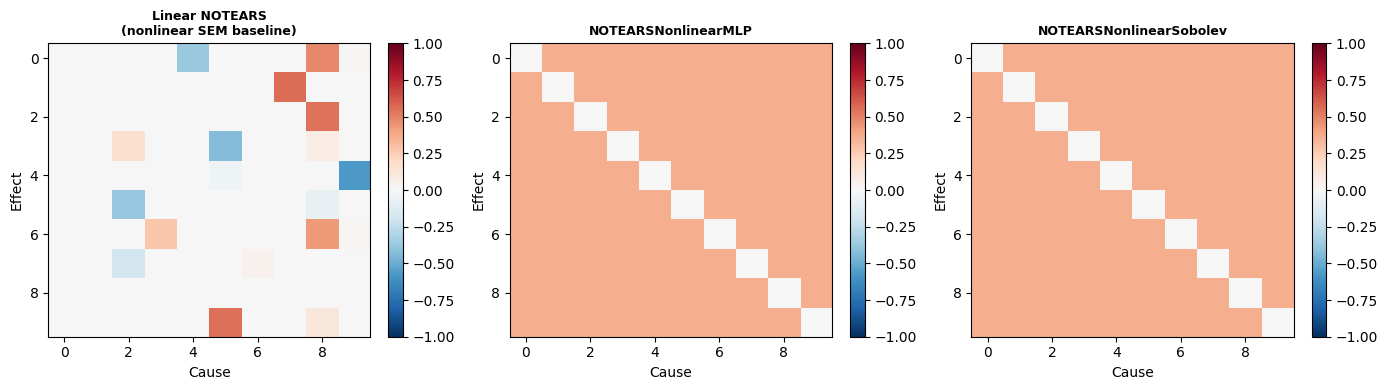

In [17]:
def make_heatmap(W, title_str, lim=1.0):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(W, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_title(title_str, fontsize=9, fontweight="bold")
    ax.set_xlabel("Cause")
    ax.set_ylabel("Effect")
    plt.colorbar(im, ax=ax, fraction=0.046)
    return fig

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, W, title in zip(
    axes,
    [W_lin_nlin, W_mlp_nlin, W_sob_nlin],
    ["Linear NOTEARS\n(nonlinear SEM baseline)", "NOTEARSNonlinearMLP", "NOTEARSNonlinearSobolev"],
):
    im = ax.imshow(W, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Cause")
    ax.set_ylabel("Effect")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### Visualization — Learned DAGs


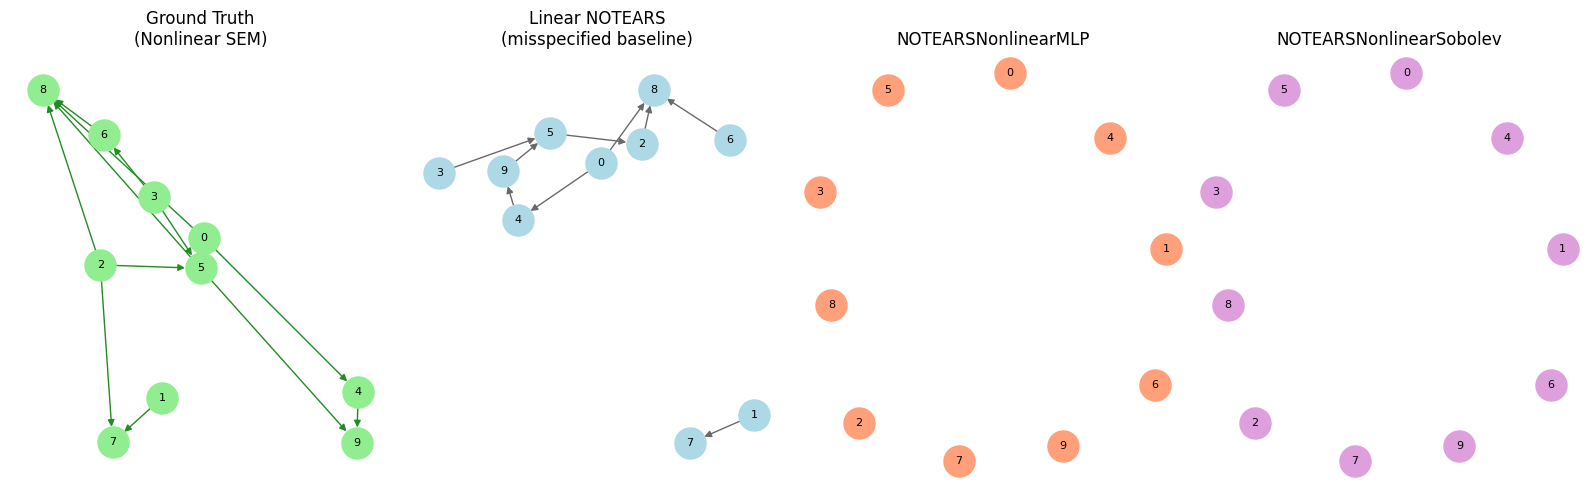

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

def plot_dag_ax(ax, B, title, node_color="lightblue", edge_color="dimgray"):
    G = nx.from_numpy_array(B.astype(int), create_using=nx.DiGraph)
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=node_color, edge_color=edge_color,
            arrows=True, node_size=500, font_size=8)
    ax.set_title(title)

plot_dag_ax(axes[0], B_true_nlin, "Ground Truth\n(Nonlinear SEM)", "lightgreen", "forestgreen")
plot_dag_ax(axes[1], B_lin_nlin, "Linear NOTEARS\n(misspecified baseline)")
B_plot_mlp = B_mlp_nlin if acc_mlp_on_nlin else np.zeros((d_nlin, d_nlin))
B_plot_sob = B_sob_nlin if acc_sob_on_nlin else np.zeros((d_nlin, d_nlin))
plot_dag_ax(axes[2], B_plot_mlp, "NOTEARSNonlinearMLP", "lightsalmon", "tomato")
plot_dag_ax(axes[3], B_plot_sob, "NOTEARSNonlinearSobolev", "plum", "purple")
plt.tight_layout()
plt.show()


### Interpretation

Linear NOTEARS on nonlinear data is a deliberate stress test. Nonlinear variants tend to outperform when sample size is sufficient ($n \geq 500$ per variable).

DAG validity must be verified with `is_dag()` before interpreting any structural metric.





## Summary and Conclusion

NOTEARS transformed causal structure learning by replacing an NP-hard combinatorial search with a smooth continuous optimization problem.

**Strengths.** The linear variant is simple, fast on moderate graphs ($d \leq 200$), and produces interpretable weighted edges.

**Limitations.** The linear variant assumes additive Gaussian noise with no hidden confounders. Always center or standardize variables before fitting.





## Resources

- **Original Paper**: [DAGs with NO TEARS (Zheng et al., 2018)](https://arxiv.org/abs/1803.01422)
- **Official Code**: [github.com/xunzheng/notears](https://github.com/xunzheng/notears)
- **PyDeepCausalML**: `pydeepcausalml.discovery.NOTEARSLinear`, `NOTEARSNonlinearMLP`, `NOTEARSNonlinearSobolev`
